In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
len(df)

18000

In [6]:
train_data = df.head(8000)
test_data = df.tail(8000)

In [7]:
train_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid3,166.0,172.0,170.0,170.0,174.0,170.0,164.0
1,odroid3,164.0,165.0,167.0,166.0,166.0,166.0,166.0
2,rpi-8a,216.4,411.6,233.2,233.3,433.7,16.4,16.2
3,rpi-8d,15.0,14.3,1595.6,24.7,9.2,16.8,16.1
4,odroid1,166.0,167.0,167.0,168.0,166.0,169.0,167.0
...,...,...,...,...,...,...,...,...
7995,rpi-8a,17.0,15.2,212.7,215.0,199.9,216.2,417.2
7996,rpi-8c,1888.7,22.0,16.3,18.3,18.1,18.4,20.0
7997,odroid4,183.0,171.0,175.0,175.0,177.0,176.0,173.0
7998,rpi-8b,230.2,433.2,16.9,232.8,233.2,433.1,16.8


In [8]:
test_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
10000,rpi-8a,433.3,13.5,15.3,216.3,216.6,199.9,216.5
10001,odroid2,164.0,183.0,167.0,166.0,166.0,167.0,183.0
10002,odroid4,171.0,173.0,173.0,173.0,171.0,172.0,173.0
10003,rpi-8b,225.4,231.9,232.7,233.2,434.0,16.0,434.1
10004,rpi-8d,15.9,18.2,75.9,1328.5,19.4,17.1,18.7
...,...,...,...,...,...,...,...,...
17995,rpi-8b,14.8,229.8,233.2,433.3,17.1,232.6,232.5
17996,rpi-8b,231.0,432.6,16.1,233.1,433.4,16.6,233.0
17997,rpi-8c,18.6,17.0,18.6,50.2,48.1,18.8,96.0
17998,odroid1,165.0,168.0,167.0,165.0,166.0,168.0,168.0


In [9]:
predictor = TabularPredictor.load("ag-20240916_042643")

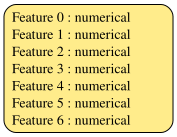

In [10]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(test_data.iloc[:, 1:])
metadata.visualize()

In [11]:
iot_device_labels = list(test_data['label'].unique())
dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']
gaussian_results = pd.DataFrame(columns=['device', 'distribution', 'accuracy', 'balanced_accuracy', 'mcc'])

for iot_device in iot_device_labels:
    for dist in dists:
        synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
        synthesizer.fit(train_data[train_data['label'] == iot_device].iloc[:, 1:].iloc[:500, :])
        synthetic_data = synthesizer.sample(num_rows=1000)
        synthetic_data['label'] = iot_device
        y_pred = predictor.predict(synthetic_data)
        y_pred_proba = predictor.predict_proba(synthetic_data)
        results = predictor.evaluate(synthetic_data)
        new_results = {'device':iot_device, 'distribution':dist, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
        gaussian_results.loc[len(gaussian_results)] = (new_results)

/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/sdv/single_table/base.py:97: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [12]:
gaussian_results

,device,distribution,accuracy,balanced_accuracy,mcc
0,rpi-8a,norm,0.214,0.901750,0.0
1,rpi-8a,beta,0.091,0.886375,0.0
2,rpi-8a,truncnorm,0.116,0.901778,0.0
3,rpi-8a,uniform,0.079,0.897667,0.0
4,rpi-8a,gamma,0.179,0.908778,0.0
5,rpi-8a,gaussian_kde,0.282,0.920222,0.0
6,odroid2,norm,0.178,0.897250,0.0
7,odroid2,beta,0.139,0.904333,0.0
8,odroid2,truncnorm,0.147,0.893375,0.0
9,odroid2,uniform,0.065,0.896111,0.0


# Which distributions are able to fool the model?

gaussian_kde was able to fool the model for the odroids, but was unable to capture a meaningful distribution for the raspberry pis. The uniform and beta distributions had limited success in capturing the distribution of the raspberry pis.

<Axes: xlabel='distribution', ylabel='accuracy'>

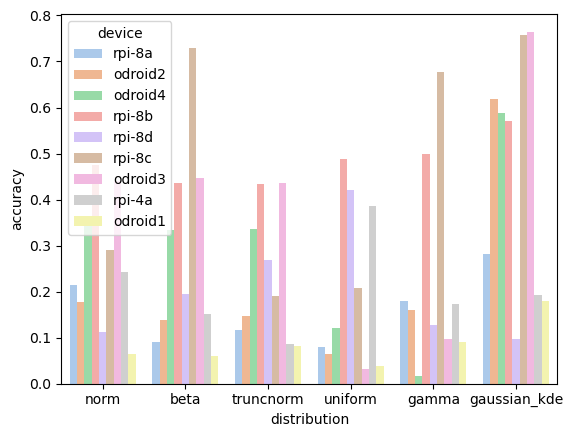

In [13]:
sns.barplot(data=gaussian_results, x='distribution', y='accuracy', hue='device', palette="pastel", linewidth=2.5)

# Training a model to deal with gaussian copula

In [14]:
bad_data_train = pd.DataFrame()
synthetic_data = pd.DataFrame()
for iot_device in iot_device_labels:
    for dist in dists:
        synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
        synthesizer.fit(train_data[train_data['label'] == iot_device].iloc[:, 1:])
        synthetic_data = synthesizer.sample(num_rows=100)
        synthetic_data['label'] = 'bad'
        bad_data_train = pd.concat([synthetic_data, bad_data_train])

In [15]:
len(bad_data_train)

5400

In [16]:
good_training_data = train_data.copy()
good_training_data['label'] = 'good'

In [17]:
len(good_training_data)

8000

In [18]:
good_bad_train = pd.concat([bad_data_train, good_training_data])

In [19]:
len(good_bad_train)

13400

In [20]:
bad_data_test = pd.DataFrame()
synthetic_data = pd.DataFrame()
dist_mask = []
for iot_device in iot_device_labels:
    for dist in dists:
        n_rows = 65
        synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
        synthesizer.fit(test_data[test_data['label'] == iot_device].iloc[:, 1:].iloc[500:, :])
        synthetic_data = synthesizer.sample(num_rows=n_rows)
        for _ in range(n_rows):
            dist_mask.append(dist)
        synthetic_data['label'] = 'bad'
        bad_data_test = pd.concat([synthetic_data, bad_data_test])

In [21]:
len(bad_data_test)

3510

In [22]:
good_data_test = pd.DataFrame()
for iot_device in iot_device_labels:
    good = test_data[test_data['label'] == iot_device].iloc[500:, :]
    good['label'] = 'good'
    good_data_test = pd.concat([good_data_test, good])

In [23]:
len(good_data_test)

3500

In [24]:
good_bad_test = pd.concat([good_data_test, bad_data_test], ignore_index=True)

In [25]:
len(good_bad_test)

7010

In [26]:
predictor = TabularPredictor(label='label').fit(good_bad_train, num_gpus=1, presets='medium_quality')
y_pred = predictor.predict(good_bad_test)
y_pred_proba = predictor.predict_proba(good_bad_test)
results = predictor.evaluate(good_bad_test)

No path specified. Models will be saved in: "AutogluonModels/ag-20240917_034835"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #44-Ubuntu SMP PREEMPT_DYNAMIC Tue Aug 13 13:35:26 UTC 2024
CPU Count:          12
Memory Avail:       21.94 GB / 23.34 GB (94.0%)
Disk Space Avail:   249.78 GB / 341.37 GB (73.2%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240917_034835"
Train Data Rows:    13400
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['bad', 'good']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 

In [27]:
good_bad_test

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,good,230.4,230.0,433.4,16.5,232.8,233.3,433.6
1,good,229.6,233.0,432.9,16.6,233.2,233.2,233.4
2,good,14.3,231.0,230.7,434.3,15.7,233.1,16.0
3,good,230.7,231.9,433.3,16.6,232.2,233.2,433.4
4,good,215.3,196.3,434.1,232.8,233.3,434.3,15.7
...,...,...,...,...,...,...,...,...
7005,bad,208.1,352.1,44.0,162.5,254.8,8.9,477.2
7006,bad,430.3,8.3,30.8,360.1,312.8,263.6,344.6
7007,bad,404.6,325.2,8.2,490.8,212.0,303.2,178.1
7008,bad,349.6,222.6,168.2,209.8,15.2,326.2,452.9


In [28]:
y_pred

0       good
1       good
2       good
3       good
4       good
        ... 
7005     bad
7006     bad
7007     bad
7008     bad
7009     bad
Name: label, Length: 7010, dtype: object

In [29]:
missed_norm = 0
missed_beta = 0
missed_truncnorm = 0
missed_uniform = 0
missed_gamma = 0
missed_gaussian = 0
accuracy_after_adversarial_training = pd.DataFrame(columns=['distribution', 'accuracy (AD)', 'accuracy (no AD)'])
for (predicition, label, dist) in zip(y_pred[3501:], good_bad_test['label'][3501:].squeeze(axis=0), dist_mask):
    if predicition == 'good' and label == 'bad':
        if dist == 'norm':
            missed_norm +=1
        elif dist == 'beta':
            missed_beta += 1
        elif dist == 'truncnorm':
            missed_truncnorm += 1
        elif dist == 'uniform':
            missed_uniform +=1
        elif dist == 'gamma':
            missed_gamma += 1
        else:
            missed_gaussian += 1

  

In [30]:
accuracy_after_adversarial_training.loc[len(accuracy_after_adversarial_training)] = {'distribution':'norm', 'accuracy (AD)': round((missed_norm / 390) * 100, 2)}
accuracy_after_adversarial_training.loc[len(accuracy_after_adversarial_training)] = {'distribution':'beta', 'accuracy (AD)': round((missed_beta / 390) * 100, 2)}
accuracy_after_adversarial_training.loc[len(accuracy_after_adversarial_training)] = {'distribution':'truncnorm', 'accuracy (AD)': round((missed_truncnorm / 390) * 100, 2)}
accuracy_after_adversarial_training.loc[len(accuracy_after_adversarial_training)] = {'distribution':'uniform', 'accuracy (AD)': round((missed_uniform / 390) * 100, 2)}
accuracy_after_adversarial_training.loc[len(accuracy_after_adversarial_training)] = {'distribution':'gamma', 'accuracy (AD)': round((missed_gamma / 390) * 100, 2)}
accuracy_after_adversarial_training.loc[len(accuracy_after_adversarial_training)] = {'distribution':'gaussian_kde', 'accuracy (AD)': round((missed_gaussian / 390) * 100, 2)}

In [31]:
accuracy_after_adversarial_training = accuracy_after_adversarial_training.sort_values(by='distribution')

In [32]:
accuracy_before_adversarial_training = gaussian_results.drop(['mcc', 'balanced_accuracy', 'device'], axis=1)

In [33]:
accuracy_before_adversarial_training = pd.DataFrame(accuracy_before_adversarial_training.groupby('distribution')['accuracy'].mean())
accuracy_before_adversarial_training = accuracy_before_adversarial_training.sort_values(by='distribution')

In [34]:
accuracy_before_adversarial_training = accuracy_before_adversarial_training.rename(columns={'accuracy': 'accuracy (no AD)'})

In [35]:
raa = list()
for i in range(6):
    raa.append(round(accuracy_before_adversarial_training.iloc[i].iloc[0] * 100, 2))

In [36]:
accuracy_after_adversarial_training['accuracy (no AD)'] = raa

<Axes: xlabel='distribution', ylabel='value'>

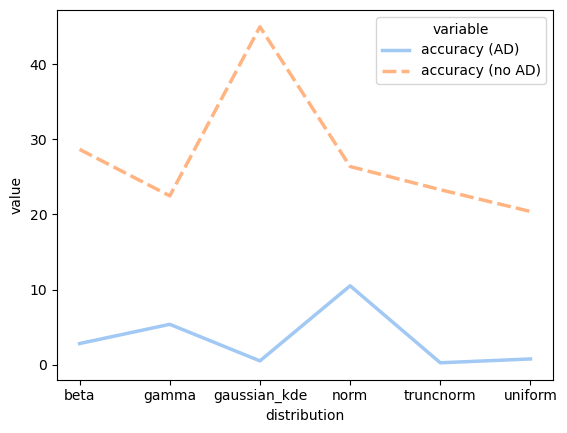

In [37]:
sns.lineplot(data=pd.melt(accuracy_after_adversarial_training, ['distribution']), x='distribution', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)